In [ ]:
import warnings
warnings.filterwarnings("ignore")

import  pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import accuracy_score, mean_squared_error


sns.set_style('darkgrid')
sns.set_palette('Set2')

print("Module Loaded")


Module Loaded


In [ ]:
import pandas as pd
data=pd.read_csv("/content/Solar Power Plant Data.csv")

In [ ]:
data.head(5)

,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
0,01.01.2017-00:00,0.6,0,1003.8,-7.4,0.1,97,0.0
1,01.01.2017-01:00,1.7,0,1003.5,-7.4,-0.2,98,0.0
2,01.01.2017-02:00,0.6,0,1003.4,-6.7,-1.2,99,0.0
3,01.01.2017-03:00,2.4,0,1003.3,-7.2,-1.3,99,0.0
4,01.01.2017-04:00,4.0,0,1003.1,-6.3,3.6,67,0.0


In [ ]:
data.describe()

,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2.639823,11.180479,1010.361781,97.538493,6.978893,76.719406,684.746071
std,1.628754,21.171295,12.793971,182.336029,7.604266,19.278996,1487.454665
min,0.000000,0.000000,965.900000,-9.300000,-12.400000,13.000000,0.000000
25%,1.400000,0.000000,1002.800000,-6.200000,0.500000,64.000000,0.000000
50%,2.300000,0.000000,1011.000000,-1.400000,6.400000,82.000000,0.000000
75%,3.600000,7.000000,1018.200000,115.600000,13.400000,93.000000,464.249950
max,10.900000,60.000000,1047.300000,899.700000,27.100000,100.000000,7701.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date-Hour(NMT)       8760 non-null   object 
 1   WindSpeed            8760 non-null   float64
 2   Sunshine             8760 non-null   int64  
 3   AirPressure          8760 non-null   float64
 4   Radiation            8760 non-null   float64
 5   AirTemperature       8760 non-null   float64
 6   RelativeAirHumidity  8760 non-null   int64  
 7   SystemProduction     8760 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 547.6+ KB


In [ ]:
data.isnull().sum()

,0
Date-Hour(NMT),0
WindSpeed,0
Sunshine,0
AirPressure,0
Radiation,0
AirTemperature,0
RelativeAirHumidity,0
SystemProduction,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.shape

(8760, 8)

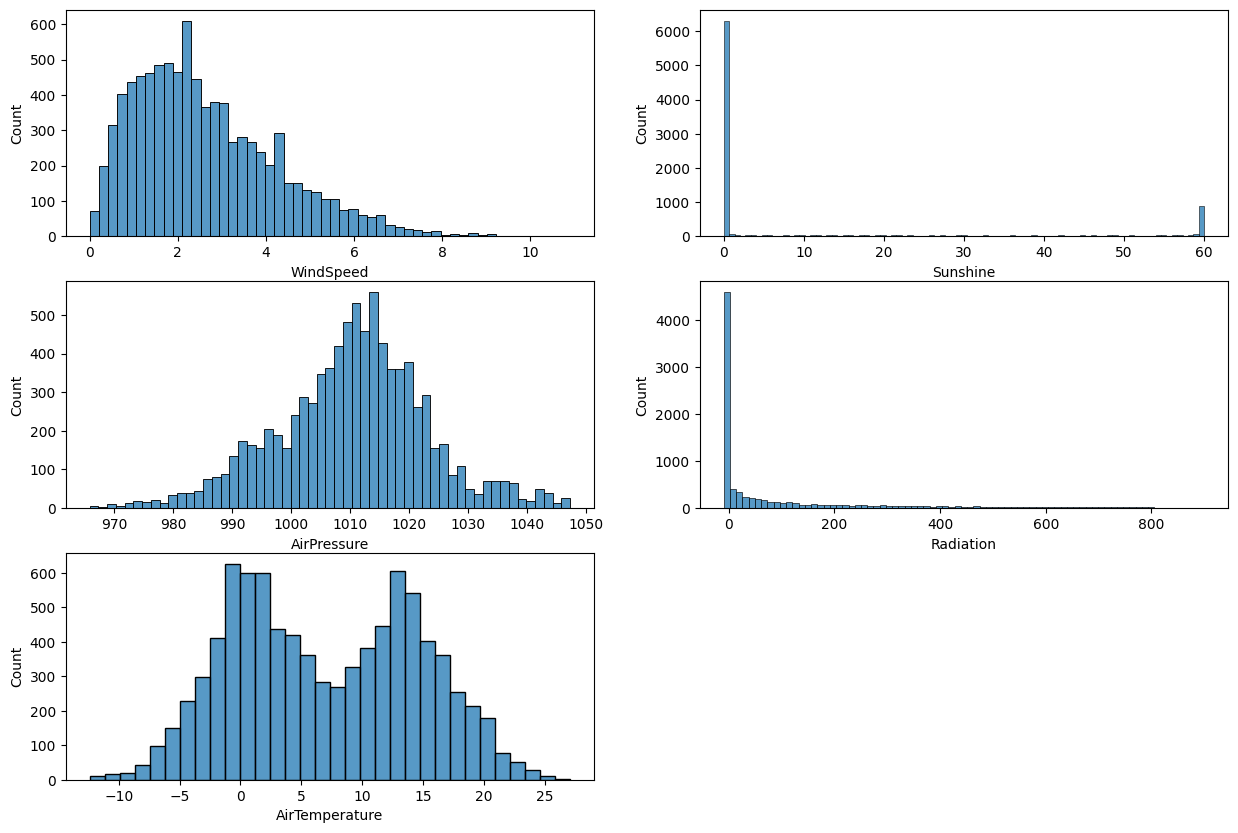

In [ ]:
i=1
plt.figure(figsize=(15,10))
for col in data.iloc[:,1:6].columns:
    plt.subplot(3,2,i)
    sns.histplot(data[col])
    i=i+1

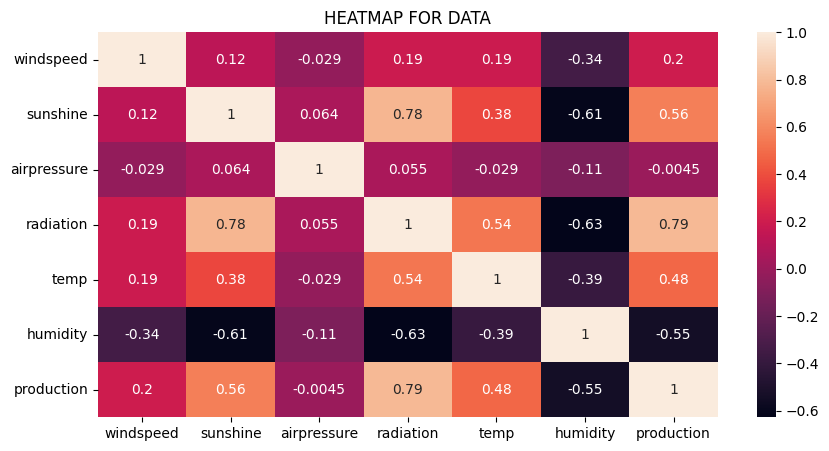

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.heatmap(data.select_dtypes(include=np.number).corr(),annot=True)
plt.title("HEATMAP FOR DATA")
plt.show()

In [ ]:
data.columns=['date','windspeed','sunshine','airpressure','radiation','temp','humidity','production']

In [ ]:
data.index=pd.to_datetime(data.date)

In [ ]:
data['date']=pd.to_datetime(data['date'])

In [ ]:
data['year']=data['date'].dt.year
data['month']=data['date'].dt.month
data['day']=data['date'].dt.day
data['hour']=data['date'].dt.hour


In [ ]:

data.head()

,date,windspeed,sunshine,airpressure,radiation,temp,humidity,production,year,month,day,hour
date,,,,,,,,,,,,
2017-01-01 00:00:00,2017-01-01 00:00:00,0.6,0,1003.8,-7.4,0.1,97,0.0,2017,1,1,0
2017-01-01 01:00:00,2017-01-01 01:00:00,1.7,0,1003.5,-7.4,-0.2,98,0.0,2017,1,1,1
2017-01-01 02:00:00,2017-01-01 02:00:00,0.6,0,1003.4,-6.7,-1.2,99,0.0,2017,1,1,2
2017-01-01 03:00:00,2017-01-01 03:00:00,2.4,0,1003.3,-7.2,-1.3,99,0.0,2017,1,1,3
2017-01-01 04:00:00,2017-01-01 04:00:00,4.0,0,1003.1,-6.3,3.6,67,0.0,2017,1,1,4


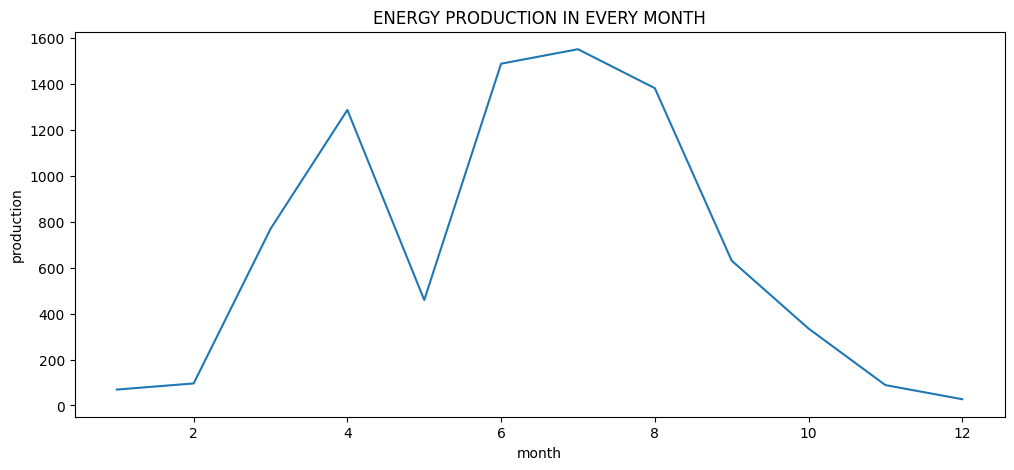

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(data.groupby(by='month')['production'].mean())
plt.title("ENERGY PRODUCTION IN EVERY MONTH")
plt.show()

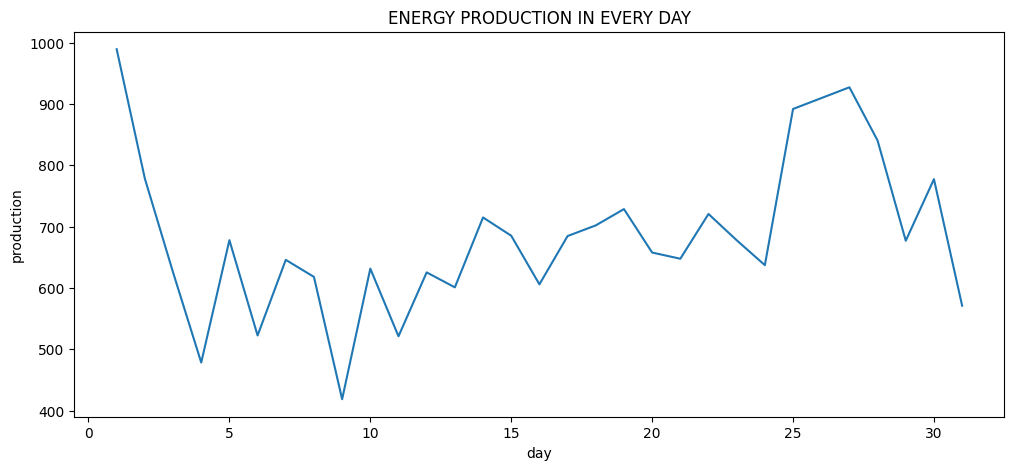

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(data.groupby(by='day')['production'].mean())
plt.title("ENERGY PRODUCTION IN EVERY DAY")
plt.show()

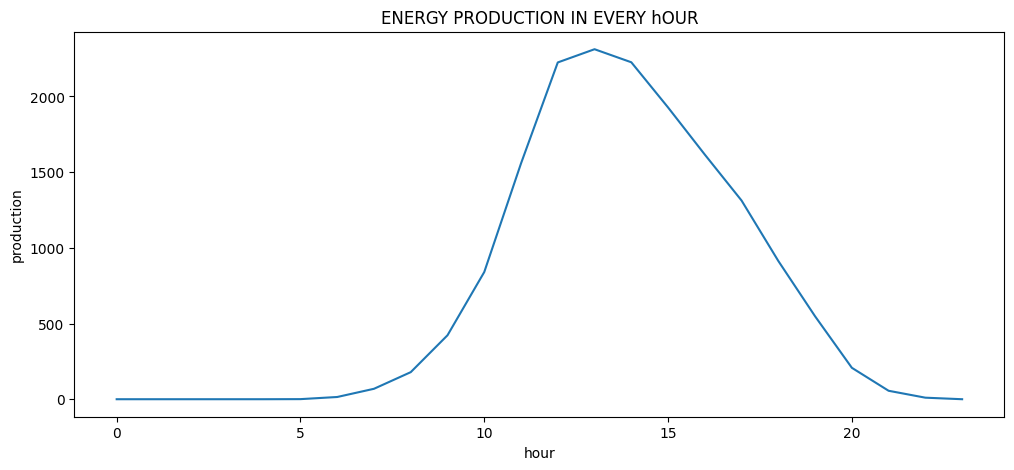

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(data.groupby(by='hour')['production'].mean())
plt.title("ENERGY PRODUCTION IN EVERY hOUR")
plt.show()

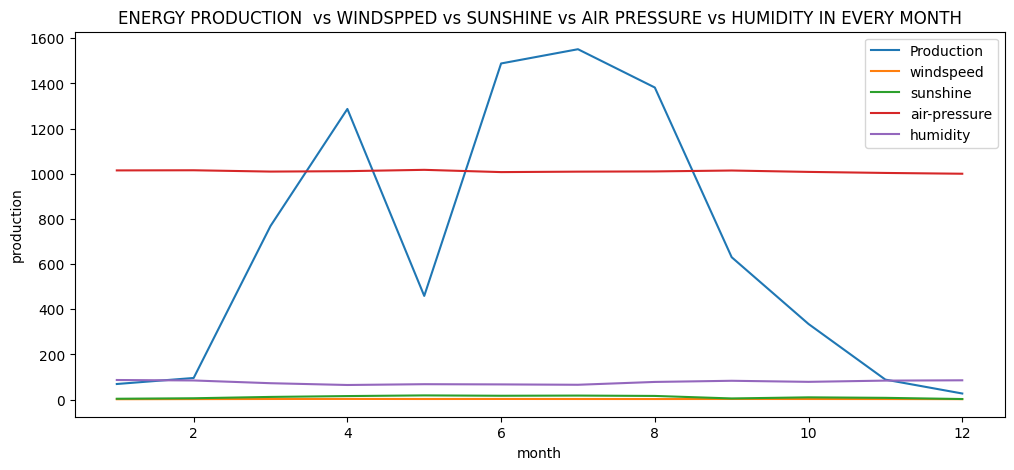

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(data.groupby(by='month')['production'].mean(),label="Production")
sns.lineplot(data.groupby(by='month')['windspeed'].mean(),label="windspeed")
sns.lineplot(data.groupby(by='month')['sunshine'].mean(),label="sunshine")
sns.lineplot(data.groupby(by='month')['airpressure'].mean(),label="air-pressure")
sns.lineplot(data.groupby(by='month')['humidity'].mean(),label="humidity")
plt.title("ENERGY PRODUCTION  vs WINDSPPED vs SUNSHINE vs AIR PRESSURE vs HUMIDITY IN EVERY MONTH")
plt.legend()
plt.show()


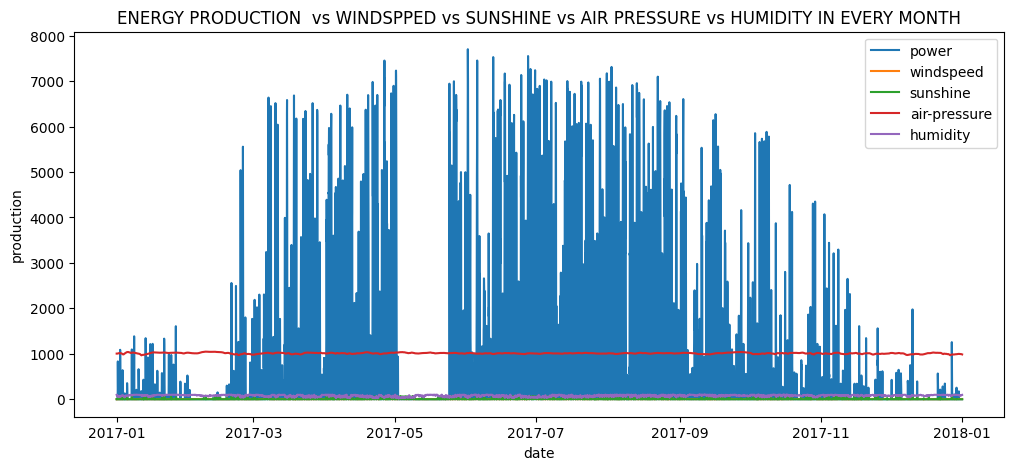

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(data['production'],label="power")
sns.lineplot(data['windspeed'],label="windspeed")
sns.lineplot(data['sunshine'],label="sunshine")
sns.lineplot(data['airpressure'],label="air-pressure")
sns.lineplot(data['humidity'],label="humidity")
plt.title("ENERGY PRODUCTION  vs WINDSPPED vs SUNSHINE vs AIR PRESSURE vs HUMIDITY IN EVERY MONTH")
plt.legend()
plt.show()

In [ ]:
tempdata=data[['production']]

tempdata.index=pd.to_datetime(data.date)

In [ ]:
from statsmodels.tsa.stattools import adfuller

adfuller_result=adfuller(tempdata,autolag='AIC')

print(f' ADF Statitcs :{adfuller_result[0]}')

print(f' p values :{adfuller_result[1]}')

for key,value in adfuller_result[4].items():
    print('criteria value')
    print(f'{key}{value}')

 ADF Statitcs :-6.973624314762037
 p values :8.538955273254052e-10
criteria value
1%-3.431099195237286
criteria value
5%-2.8618710944295014
criteria value
10%-2.566946236596859


In [ ]:
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error

# Assuming you have your time series data in the 'data' variable

# Create and fit the ARIMA model
p, d, q = (1, 1, 1)  # Example values, replace with appropriate values
model = ARIMA(tempdata, order=(p, d, q))
result = model.fit()

# Perform the Augmented Dickey-Fuller test
# Make predictions for the next year ('01/01/1990' to '01/01/1991')
predictions = result.predict(start='2017/01/01', end='2017/12/31')

# Print the predicted values for the next year
print(predictions)


2017-01-01 00:00:00    0.000000e+00
2017-01-01 01:00:00    0.000000e+00
2017-01-01 02:00:00    0.000000e+00
2017-01-01 03:00:00    0.000000e+00
2017-01-01 04:00:00    0.000000e+00
                           ...     
2017-12-31 19:00:00   -1.925495e-16
2017-12-31 20:00:00   -4.620142e-17
2017-12-31 21:00:00   -1.108583e-17
2017-12-31 22:00:00   -2.659997e-18
2017-12-31 23:00:00   -6.382547e-19
Freq: h, Name: predicted_mean, Length: 8760, dtype: float64


In [ ]:
actual=data['production']

In [ ]:
actual=data['2017/01/01':'2017/04/24']['production'][0:1000]

In [ ]:
actual


,production
date,
2017-01-01 00:00:00,0.0000
2017-01-01 01:00:00,0.0000
2017-01-01 02:00:00,0.0000
2017-01-01 03:00:00,0.0000
2017-01-01 04:00:00,0.0000
...,...
2017-02-11 11:00:00,0.0000
2017-02-11 12:00:00,0.0000
2017-02-11 13:00:00,21.1667


In [ ]:
predictions

,predicted_mean
2017-01-01 00:00:00,0.000000e+00
2017-01-01 01:00:00,0.000000e+00
2017-01-01 02:00:00,0.000000e+00
2017-01-01 03:00:00,0.000000e+00
2017-01-01 04:00:00,0.000000e+00
...,...
2017-12-31 19:00:00,-1.925495e-16
2017-12-31 20:00:00,-4.620142e-17
2017-12-31 21:00:00,-1.108583e-17
2017-12-31 22:00:00,-2.659997e-18


In [ ]:
actual_array = actual.values
predictions_array = predictions.values

# Align the arrays if needed (e.g., by slicing the larger array to match the smaller one)
min_samples = min(len(actual_array), len(predictions_array))
actual_array_aligned = actual_array[:min_samples]
predictions_array_aligned = predictions_array[:min_samples]

# Reshape the arrays to be 2D arrays
actual_2d = actual_array_aligned.reshape(-1, 1)
predictions_2d = predictions_array_aligned.reshape(-1, 1)

# Calculate mean absolute error
mae = mean_absolute_error(actual_2d, predictions_2d)

print(mae)


40.83786133132919


In [ ]:
data.reset_index(drop=True, inplace=True)

In [ ]:
data.head()

,date,windspeed,sunshine,airpressure,radiation,temp,humidity,production,year,month,day,hour
0,2017-01-01 00:00:00,0.6,0,1003.8,-7.4,0.1,97,0.0,2017,1,1,0
1,2017-01-01 01:00:00,1.7,0,1003.5,-7.4,-0.2,98,0.0,2017,1,1,1
2,2017-01-01 02:00:00,0.6,0,1003.4,-6.7,-1.2,99,0.0,2017,1,1,2
3,2017-01-01 03:00:00,2.4,0,1003.3,-7.2,-1.3,99,0.0,2017,1,1,3
4,2017-01-01 04:00:00,4.0,0,1003.1,-6.3,3.6,67,0.0,2017,1,1,4


In [ ]:
x=data.drop(['production','date'],axis=1)
y=data[['production']]

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30)


In [ ]:
from sklearn.preprocessing import  StandardScaler
scaler=StandardScaler()

x_train=pd.DataFrame(scaler.fit_transform(x_train),columns=x_train.columns)
x_test=pd.DataFrame(scaler.fit_transform(x_test),columns=x_test.columns)


x_test.head()

,windspeed,sunshine,airpressure,radiation,temp,humidity,year,month,day,hour
0,2.091483,2.337759,0.052571,1.458431,0.611924,-1.032617,0.0,-0.730665,-0.757188,0.642926
1,1.287611,-0.518858,-0.371032,-0.564843,-0.177660,-0.876441,0.0,0.997677,-0.870689,-1.370227
2,-0.629317,-0.518858,0.554620,-0.312691,-1.485004,1.049733,0.0,-1.306779,0.264316,-0.219853
3,0.545574,-0.518858,-0.590678,0.137660,-0.488316,0.685321,0.0,-0.730665,-0.303186,0.355333
4,-0.752990,-0.518858,-2.810672,-0.568697,-0.876636,0.841498,0.0,-1.306779,0.718318,1.649503


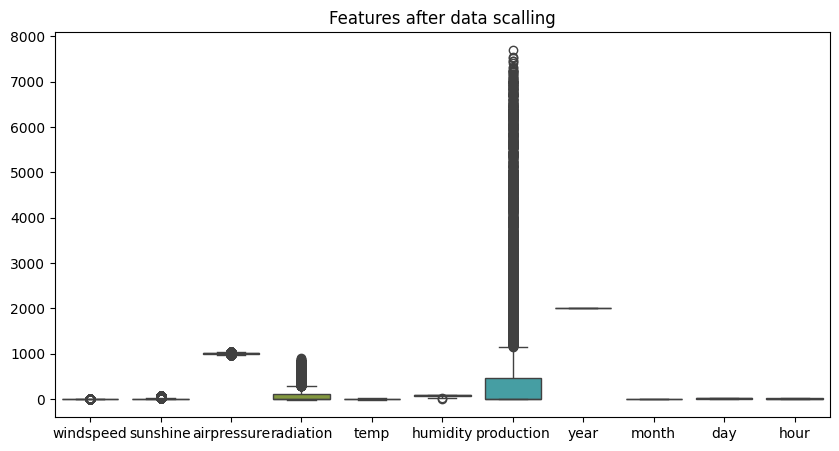

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Features after data scalling")
sns.boxplot(data)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.feature_selection import SelectKBest

In [ ]:
linear_pipeline = Pipeline([
    ('model', LinearRegression())
])

rf_pipeline = Pipeline([
    ('selector', SelectKBest(k=10)),
    ('model', RandomForestRegressor())
])

svm_pipeline = Pipeline([
    ('model', SVR())
])

In [ ]:
linear_pipeline .fit(x_train, y_train)
logistic_y_pred = linear_pipeline .predict(x_test)
print("linear regression score",linear_pipeline.score(x_test,y_test))

# Fit and make predictions for Random Forest pipeline
rf_pipeline.fit(x_train, y_train)
rf_y_pred = rf_pipeline.predict(x_test)
print("random forest score",rf_pipeline.score(x_test,y_test))


# Fit and make predictions for SVM pipeline
svm_pipeline.fit(x_train, y_train)
svm_y_pred = svm_pipeline.predict(x_test)
print("support  vector regression",svm_pipeline.score(x_test,y_test))


linear regression score 0.640740325496568
random forest score 0.8527697824984218
support  vector regression -0.040377500291541635


In [ ]:
logistic_accuracy = mean_absolute_error(y_test, logistic_y_pred)
print("Logistic Regression Accuracy:", logistic_accuracy)

rf_accuracy = mean_absolute_error(y_test, rf_y_pred)
print("Random Forest Accuracy:", rf_accuracy)

svm_accuracy = mean_absolute_error(y_test, svm_y_pred)
print("SVM Accuracy:", svm_accuracy)

Logistic Regression Accuracy: 474.9939769429221
Random Forest Accuracy: 236.4876483807712
SVM Accuracy: 612.6878430112666


Dataset Shape: (8760, 8)
     Date-Hour(NMT)  WindSpeed  Sunshine  AirPressure  Radiation  \
0  01.01.2017-00:00        0.6         0       1003.8       -7.4   
1  01.01.2017-01:00        1.7         0       1003.5       -7.4   
2  01.01.2017-02:00        0.6         0       1003.4       -6.7   
3  01.01.2017-03:00        2.4         0       1003.3       -7.2   
4  01.01.2017-04:00        4.0         0       1003.1       -6.3   

   AirTemperature  RelativeAirHumidity  SystemProduction  
0             0.1                   97               0.0  
1            -0.2                   98               0.0  
2            -1.2                   99               0.0  
3            -1.3                   99               0.0  
4             3.6                   67               0.0  

Model Comparison
               Model  R2 Score         MAE         RMSE
0  Linear Regression  0.612264  461.702548   875.852002
1   Ridge Regression  0.612270  461.737637   875.845681
2   Lasso Regression  0.61

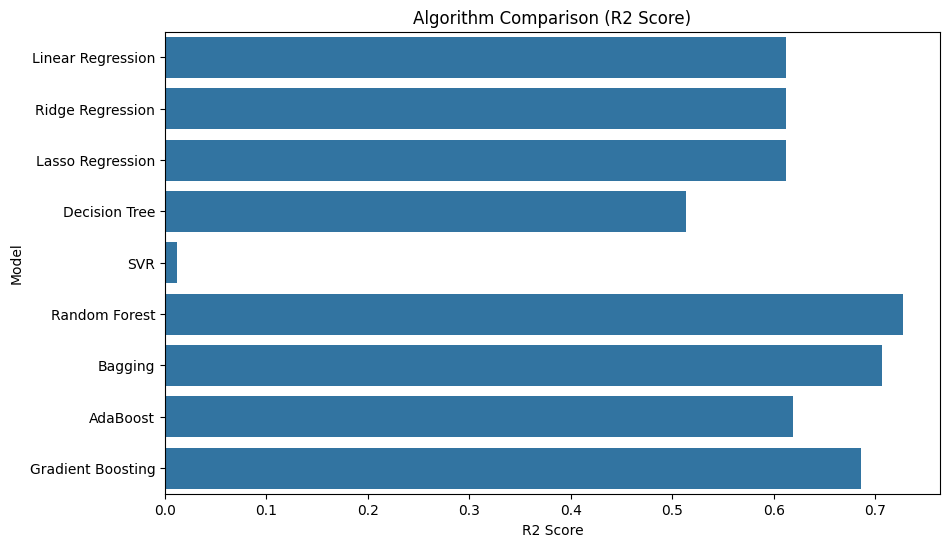

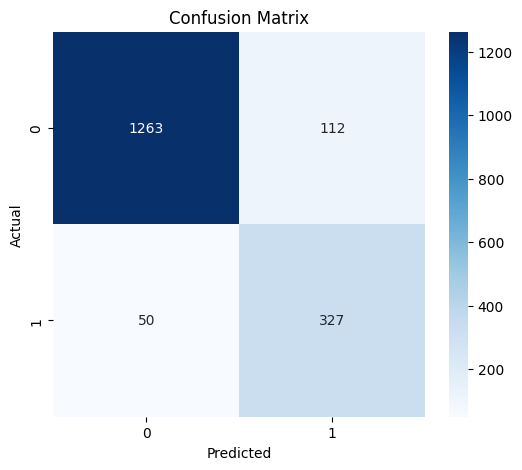

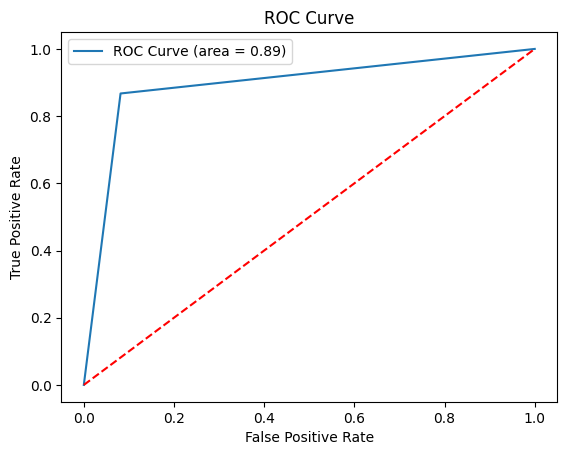


Best Model:
           Model  R2 Score         MAE        RMSE
5  Random Forest  0.727515  329.500883  734.233605


In [ ]:

# Solar Power Forecasting ML Project


# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, AdaBoostRegressor, GradientBoostingRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, roc_curve, auc


# 2. Load Dataset


file_path = "/content/Solar Power Plant Data.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print(df.head())


# 3. Data Cleaning


df = df.dropna()

# Assume last column is target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Drop the non-numerical 'Date-Hour(NMT)' column from features
X = X.drop('Date-Hour(NMT)', axis=1)


# 4. Train Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# 5. Feature Scaling


scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 6. Define Models


models = {

"Linear Regression": LinearRegression(),
"Ridge Regression": Ridge(),
"Lasso Regression": Lasso(),
"Decision Tree": DecisionTreeRegressor(),
"SVR": SVR(),
"Random Forest": RandomForestRegressor(),
"Bagging": BaggingRegressor(),
"AdaBoost": AdaBoostRegressor(),
"Gradient Boosting": GradientBoostingRegressor()

}


# 7. Train Models and Compare


results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2, mae, rmse])

results_df = pd.DataFrame(results,
columns=["Model","R2 Score","MAE","RMSE"])

print("\nModel Comparison")
print(results_df)


# 8. Algorithm Comparison Plot


plt.figure(figsize=(10,6))
sns.barplot(x="R2 Score", y="Model", data=results_df)
plt.title("Algorithm Comparison (R2 Score)")
plt.show()


# 9. Confusion Matrix (Convert Regression to Class)


threshold = y_test.mean()

y_test_class = (y_test > threshold).astype(int)

best_model = GradientBoostingRegressor()
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

y_pred_class = (y_pred > threshold).astype(int)

cm = confusion_matrix(y_test_class, y_pred_class)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 10. ROC Curve


fpr, tpr, thresholds = roc_curve(y_test_class, y_pred_class)

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label="ROC Curve (area = %0.2f)" % roc_auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()


# 11. Best Model


best = results_df.sort_values("R2 Score", ascending=False)

print("\nBest Model:")
print(best.head(1))